In [11]:
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras import layers, metrics, models, optimizers

import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torchvision.datasets as dsets

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.11.0
CUDA available: False


In [12]:
RAW_DIR       = "./data/raw"        # Where raw GTSRB data is downloaded
PROCESSED_DIR = "./data/processed"  # Where cleaned images are saved
IMAGE_SIZE      = 64                  # Output resolution (64 or 128 recommended)
MAX_PER_CLASS = 200                 # Max images sampled per sign class
BATCH_SIZE    = 64                  # DataLoader batch size
SEED          = 42                  # Reproducibility
DATASET_REPETITIONS = 1
EPOCHS = 20
EMA = 0.999
LEARNING_RATE = 1e-4

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [13]:
Path(RAW_DIR).mkdir(parents=True, exist_ok=True)

print("Downloading GTSRB training set...")
train_dataset = dsets.GTSRB(root=RAW_DIR, split="train", download=True)

print("Downloading GTSRB test set...")
test_dataset = dsets.GTSRB(root=RAW_DIR, split="test", download=True)

print(f"\nTrain samples : {len(train_dataset):,}")
print(f"Test samples  : {len(test_dataset):,}")


Train samples : 26,640
Test samples  : 12,630


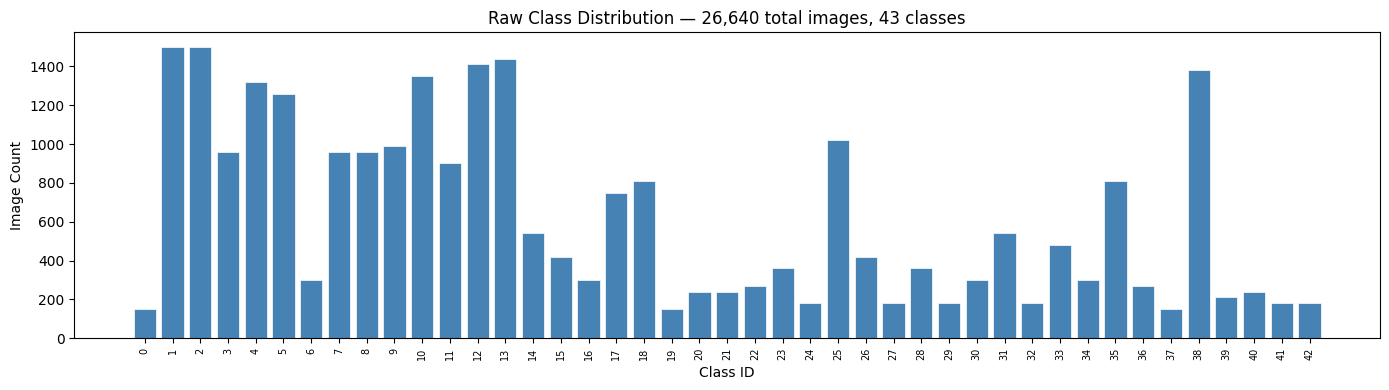

Min images in a class : 150
Max images in a class : 1500
Mean per class        : 620


In [14]:
raw_counts = {}
for _, label in train_dataset:
    raw_counts[label] = raw_counts.get(label, 0) + 1

classes = sorted(raw_counts.keys())
counts  = [raw_counts[c] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, counts, color="steelblue", edgecolor="white", linewidth=0.5)
plt.xlabel("Class ID")
plt.ylabel("Image Count")
plt.title(f"Raw Class Distribution — {len(train_dataset):,} total images, {len(classes)} classes")
plt.xticks(classes, rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Min images in a class : {min(counts)}")
print(f"Max images in a class : {max(counts)}")
print(f"Mean per class        : {sum(counts)/len(counts):.0f}")


In [15]:
def sample_per_class(dataset, max_per_class, seed=42):
    random.seed(seed)
    buckets = {}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        buckets.setdefault(label, []).append(idx)

    sampled = []
    for label, indices in sorted(buckets.items()):
        chosen = random.sample(indices, min(max_per_class, len(indices)))
        sampled.extend(chosen)

    return sampled

print(f"Sampling up to {MAX_PER_CLASS} images per class...")
sampled_indices = sample_per_class(train_dataset, MAX_PER_CLASS, seed=SEED)
print(f"Total sampled: {len(sampled_indices):,} images")


Sampling up to 200 images per class...
Total sampled: 8,330 images


In [16]:
def preprocess(pil_img, img_size):
    img = pil_img.convert("RGB")
    min_dim = min(img.size)
    if min_dim < 20:
        return None

    img = ImageOps.fit(
        img,
        (img_size, img_size),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    return img


def build_processed_dataset(dataset, indices, output_dir, img_size):
    img_dir = Path(output_dir) / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = Path(output_dir) / "manifest.csv"

    rejected = 0
    saved = 0

    with open(manifest_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "class_id"])

        for idx in indices:
            pil_img, label = dataset[idx]
            cleaned = preprocess(pil_img, img_size)
            if cleaned is None:
                rejected += 1
                continue

            filename = f"{saved:06d}_class{label:02d}.png"
            cleaned.save(img_dir / filename)
            writer.writerow([filename, label])
            saved += 1

    print(f"Saved   : {saved:,} images → {img_dir}")
    print(f"Rejected: {rejected} images (too small)")
    print(f"Manifest: {manifest_path}")
    return manifest_path

print("Cleaning and saving images...")
manifest_path = build_processed_dataset(
    train_dataset, sampled_indices, PROCESSED_DIR, IMAGE_SIZE
)


Cleaning and saving images...
Saved   : 8,330 images → data/processed/images
Rejected: 0 images (too small)
Manifest: data/processed/manifest.csv


In [17]:
class RoadSignDataset(Dataset):
    def __init__(self, processed_dir, img_size, use_labels=True):
        self.img_dir = Path(processed_dir) / "images"
        self.manifest = []
        self.use_labels = use_labels

        with open(Path(processed_dir) / "manifest.csv") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.manifest.append((row["filename"], int(row["class_id"])))

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5],
            ),
        ])

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        filename, class_id = self.manifest[idx]
        img = Image.open(self.img_dir / filename).convert("RGB")
        image = self.transform(img)
        if self.use_labels:
            return image, class_id
        return image


road_sign_dataset = RoadSignDataset(PROCESSED_DIR, IMAGE_SIZE, use_labels=True)
print(f"Dataset size: {len(road_sign_dataset):,} images")


Dataset size: 8,330 images


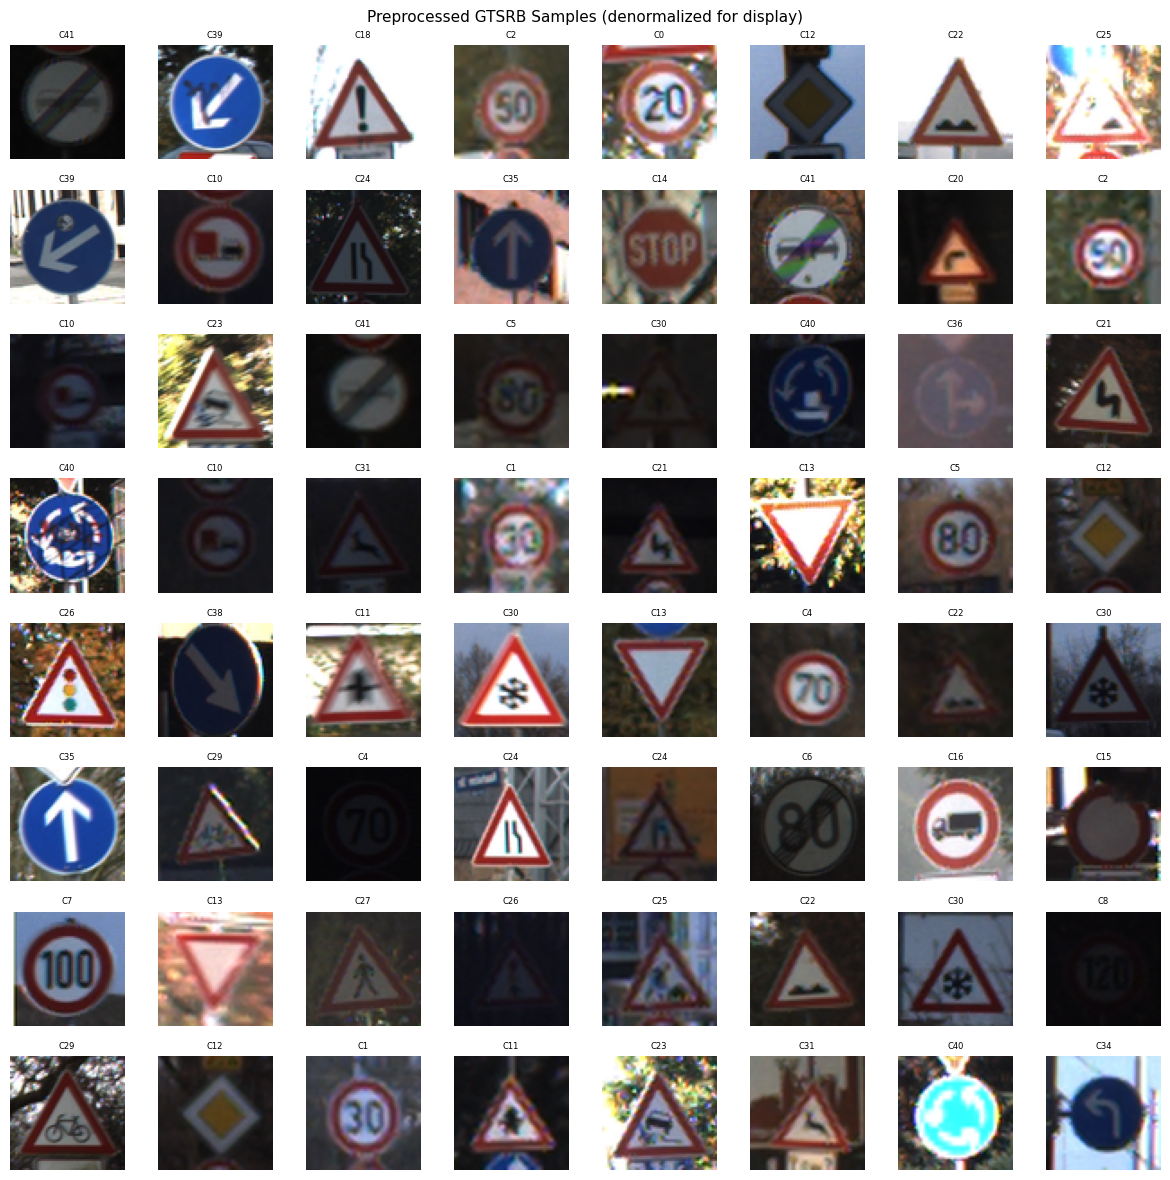

Sample grid saved.


In [18]:
def plot_sample_grid(dataset, n=64):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols = 8
    rows = (len(indices) + cols - 1) // cols

    _, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        tensor, class_id = dataset[idx]
        img_np = (tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img_np)
        axes[i].set_title(f"C{class_id}", fontsize=6)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Preprocessed GTSRB Samples (denormalized for display)", fontsize=11)
    plt.tight_layout()
    plt.savefig(Path(PROCESSED_DIR) / "sample_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Sample grid saved.")

plot_sample_grid(road_sign_dataset, n=64)


In [19]:
# Build tf.data dataset for Keras diffusion training.
manifest_file = Path(PROCESSED_DIR) / "manifest.csv"
img_root = Path(PROCESSED_DIR) / "images"

file_paths = []
labels = []
with open(manifest_file) as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_paths.append(str(img_root / row["filename"]))
        labels.append(int(row["class_id"]))

train = tf.data.Dataset.from_tensor_slices(file_paths)


def preprocess_path(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE), method="bilinear", antialias=True)
    img = tf.cast(img, tf.float32) / 255.0
    return img


train = train.map(preprocess_path, num_parallel_calls=tf.data.AUTOTUNE)
train = train.shuffle(min(len(file_paths), 1000), seed=SEED)
train = train.batch(BATCH_SIZE, drop_remainder=True)
train = train.prefetch(tf.data.AUTOTUNE)
train = train.repeat(DATASET_REPETITIONS)

print(f"Prepared tf.data train pipeline with {len(file_paths):,} images")

2026-05-01 20:47:25.003012: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-01 20:47:25.003078: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-01 20:47:25.003090: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-01 20:47:25.003871: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-01 20:47:25.004489: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Prepared tf.data train pipeline with 8,330 images


In [20]:
def offset_cosine_diffusion_schedule(diffusion_times):
    min_signal_rate = 0.02
    max_signal_rate = 0.95
    start_angle = tf.acos(max_signal_rate)
    end_angle = tf.acos(min_signal_rate)

    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

    signal_rates = tf.cos(diffusion_angles)
    noise_rates = tf.sin(diffusion_angles)

    return noise_rates, signal_rates

In [21]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, kernel_size=3, padding="same", activation="swish")(x)
    x = layers.Conv2D(filters, kernel_size=3, padding="same", activation="swish")(x)
    return x


def build_unet(image_size):
    image_input = layers.Input(shape=(image_size, image_size, 3), name="noisy_images")
    noise_input = layers.Input(shape=(1, 1, 1), name="noise_variances")

    noise_map = layers.UpSampling2D(size=(image_size, image_size), interpolation="nearest")(noise_input)
    x = layers.Concatenate()([image_input, noise_map])

    x1 = conv_block(x, 32)
    p1 = layers.MaxPool2D()(x1)

    x2 = conv_block(p1, 64)
    p2 = layers.MaxPool2D()(x2)

    x3 = conv_block(p2, 128)

    u2 = layers.UpSampling2D()(x3)
    u2 = layers.Concatenate()([u2, x2])
    x4 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(x4)
    u1 = layers.Concatenate()([u1, x1])
    x5 = conv_block(u1, 32)

    output = layers.Conv2D(3, kernel_size=1, padding="same", name="pred_noises")(x5)
    return models.Model([image_input, noise_input], output, name="simple_unet")


unet = build_unet(IMAGE_SIZE)
unet.summary()

Model: "simple_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_variances     │ (None, 1, 1, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy_images        │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64, 1) │          0 │ noise_variances[… │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64, 4) │          0 │ noisy_images[0][… │
│ (Concatenate)       │                   │            │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,184 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]  

 Total params: 471,907 (1.80 MB)

 Trainable params: 471,907 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
class DiffusionModel(models.Model):
    def __init__(self):
        super().__init__()

        self.normalizer = layers.Normalization()
        self.network = unet
        self.ema_network = models.clone_model(self.network)
        self.diffusion_schedule = offset_cosine_diffusion_schedule

    def compile(self, **kwargs):
        super().compile(**kwargs)
        self.noise_loss_tracker = metrics.Mean(name="n_loss")

    @property
    def metrics(self):
        return [self.noise_loss_tracker]

    def denormalize(self, images):
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return tf.clip_by_value(images, 0.0, 1.0)

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
        if training:
            network = self.network
        else:
            network = self.ema_network
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates
        return pred_noises, pred_images

    def train_step(self, images):
        images = self.normalizer(images, training=True)
        noises = tf.random.normal(shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3))

        diffusion_times = tf.random.uniform(shape=(BATCH_SIZE, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises

        with tf.GradientTape() as tape:
            pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=True)
            noise_loss = self.loss(noises, pred_noises)

        gradients = tape.gradient(noise_loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))
        self.noise_loss_tracker.update_state(noise_loss)

        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(EMA * ema_weight + (1 - EMA) * weight)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        images = self.normalizer(images, training=False)
        noises = tf.random.normal(shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3))
        diffusion_times = tf.random.uniform(shape=(BATCH_SIZE, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises
        pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=False)
        noise_loss = self.loss(noises, pred_noises)
        self.noise_loss_tracker.update_state(noise_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, num_images, diffusion_steps, initial_noise=None):
        if initial_noise is None:
            initial_noise = tf.random.normal(shape=(num_images, IMAGE_SIZE, IMAGE_SIZE, 3))
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
        return generated_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps
        current_images = initial_noise
        for step in range(diffusion_steps):
            diffusion_times = tf.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
            pred_noises, pred_images = self.denoise(current_images, noise_rates, signal_rates, training=False)
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(next_diffusion_times)
            current_images = (next_signal_rates * pred_images + next_noise_rates * pred_noises)
        return pred_images

In [23]:
diffusion_model = DiffusionModel()

# Adapt on one pass of batched images in [0, 1].
adapt_ds = train.take(max(1, len(file_paths) // BATCH_SIZE))
diffusion_model.normalizer.adapt(adapt_ds)

diffusion_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.MeanAbsoluteError(),
)

history = diffusion_model.fit(
    train,
    epochs=EPOCHS,
    steps_per_epoch=max(1, len(file_paths) // BATCH_SIZE),
)

print("Training complete.")

Epoch 1/20


2026-05-01 20:47:28.762710: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-01 20:47:30.349720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  1/130 ━━━━━━━━━━━━━━━━━━━━ 3:00:23 84s/step - n_loss: 0.7996

KeyboardInterrupt: 